### Implementing simple Chatbot Using LangGraph

In [2]:
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END

## Reducers
from typing import Annotated
from langgraph.graph.message import add_messages

In [3]:
class State(TypedDict):
    messages:Annotated[list,add_messages]

In [4]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GOOGLE_API_KEY"]=os.getenv("GOOGLE_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

In [9]:
from langchain_groq import ChatGroq
llm=ChatGroq(model="openai/gpt-oss-120b")
llm.invoke("Hello")

AIMessage(content='Hello! How can I help you today?', additional_kwargs={'reasoning_content': 'The user says "Hello". We need to respond politely. No special instructions. So just greet back.'}, response_metadata={'token_usage': {'completion_tokens': 40, 'prompt_tokens': 72, 'total_tokens': 112, 'completion_time': 0.082308048, 'completion_tokens_details': {'reasoning_tokens': 22}, 'prompt_time': 0.00263815, 'prompt_tokens_details': None, 'queue_time': 0.285193017, 'total_time': 0.084946198}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_c800245357', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a02cdf-fd12-7d93-9af3-a86ed9156ba0-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 72, 'output_tokens': 40, 'total_tokens': 112, 'output_token_details': {'reasoning': 22}})

### We Will start With Creating Nodes

In [11]:
from langgraph.checkpoint.memory import MemorySaver
memory=MemorySaver()
def superbot(state:State):
    return {"messages":[llm.invoke(state['messages'])]}

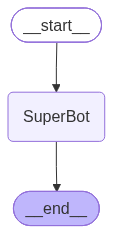

In [12]:
graph=StateGraph(State)

## node
graph.add_node("SuperBot",superbot)
## Edges

graph.add_edge(START,"SuperBot")
graph.add_edge("SuperBot",END)


graph_builder=graph.compile(checkpointer=memory)


## Display
from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [13]:
## Invocation

config = {"configurable": {"thread_id": "1"}}

graph_builder.invoke({'messages':"Hi,My name is Krish And I like cricket"},config)

{'messages': [HumanMessage(content='Hi,My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='6f6c518c-701e-4efa-805f-72afbd4e4569'),
  AIMessage(content='Hello Krish! 👋 Great to meet you.  \n\nCricket is such an exciting sport—there’s always something happening on the field. Do you have a favorite team or player you follow? Are you more into Test matches, ODIs, T20s, or maybe all of them? Let’s chat about the game!', additional_kwargs={'reasoning_content': "We need to respond. The user says hi, name Krish and likes cricket. We should respond in a friendly manner, perhaps ask about favorite teams, players, etc. Follow OpenAI policies: no disallowed content. It's a simple conversation."}, response_metadata={'token_usage': {'completion_tokens': 127, 'prompt_tokens': 82, 'total_tokens': 209, 'completion_time': 0.263093063, 'completion_tokens_details': {'reasoning_tokens': 51}, 'prompt_time': 0.01553144, 'prompt_tokens_details': None, 'queue_time': 0.30119468

### Streaming 
Methods: .stream() and astream()

- These methods are sync and async methods for streaming back results.

Additional parameters in streaming modes for graph state

- **values** : This streams the full state of the graph after each node is called.
- **updates** : This streams updates to the state of the graph after each node is called.


#### Streaming The Responses With Stream Method

In [14]:
# Create a thread
config = {"configurable": {"thread_id": "3"}}

for chunk in graph_builder.stream({'messages':"Hi,My name is Krish And I like cricket"},config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content='Hello Krish! Nice to meet you. 🎉\n\nCricket is such an exciting sport—do you have a favorite team or player? Are you more into the fast‑bowling action, the batting fireworks, or maybe the strategic side of the game? Let me know, and we can chat all things cricket!', additional_kwargs={'reasoning_content': 'The user says "Hi, My name is Krish And I like cricket". They are greeting and introducing themselves. The assistant should respond politely, perhaps ask about cricket preferences, etc. There\'s no disallowed content. Just a friendly response.'}, response_metadata={'token_usage': {'completion_tokens': 123, 'prompt_tokens': 82, 'total_tokens': 205, 'completion_time': 0.254951848, 'completion_tokens_details': {'reasoning_tokens': 49}, 'prompt_time': 0.003086453, 'prompt_tokens_details': None, 'queue_time': 0.370121474, 'total_time': 0.258038301}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_e1a78f200e', 'service_tier': 'on

In [15]:
for chunk in graph_builder.stream({'messages':"I also like football"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='3a26eaa7-ed2f-4e9f-93c1-70629317f83a'), AIMessage(content='Hello Krish! Nice to meet you. 🎉\n\nCricket is such an exciting sport—do you have a favorite team or player? Are you more into the fast‑bowling action, the batting fireworks, or maybe the strategic side of the game? Let me know, and we can chat all things cricket!', additional_kwargs={'reasoning_content': 'The user says "Hi, My name is Krish And I like cricket". They are greeting and introducing themselves. The assistant should respond politely, perhaps ask about cricket preferences, etc. There\'s no disallowed content. Just a friendly response.'}, response_metadata={'token_usage': {'completion_tokens': 123, 'prompt_tokens': 82, 'total_tokens': 205, 'completion_time': 0.254951848, 'completion_tokens_details': {'reasoning_tokens': 49}, 'prompt_time': 0.003086453, 'prompt_tokens_details': None, 'queue_time'

In [16]:
for chunk in graph_builder.stream({'messages':"I also like football "},config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content='Great! Football (soccer) adds even more excitement to your sports lineup.  \n\n**A few quick questions to get the conversation rolling:**  \n\n1. **Which league or competition do you follow the most?**  \n   - Premier League (England)  \n   - La\u202fLiga (Spain)  \n   - Serie\u202fA (Italy)  \n   - Bundesliga (Germany)  \n   - MLS (USA/Canada)  \n   - Other (e.g., Indian Super League, AFC Champions League, etc.)\n\n2. **Do you have a favorite club or national team?**  \n\n3. **What’s your favorite position or style of play?**  \n   - Creative midfielders who dictate the tempo  \n   - Lightning‑quick wingers  \n   - Clinical strikers  \n   - Rock‑solid defenders or goalkeepers  \n\n4. **Any recent match or player that caught your eye?**  \n\nFeel free to share any of the above, or let me know if you’d like to discuss:\n- Upcoming fixtures and key match‑ups  \n- Player comparisons between cricket and football (e.g., leadership, fitness)  \n-

In [17]:
for chunk in graph_builder.stream({'messages':"I Love sports "},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='3a26eaa7-ed2f-4e9f-93c1-70629317f83a'), AIMessage(content='Hello Krish! Nice to meet you. 🎉\n\nCricket is such an exciting sport—do you have a favorite team or player? Are you more into the fast‑bowling action, the batting fireworks, or maybe the strategic side of the game? Let me know, and we can chat all things cricket!', additional_kwargs={'reasoning_content': 'The user says "Hi, My name is Krish And I like cricket". They are greeting and introducing themselves. The assistant should respond politely, perhaps ask about cricket preferences, etc. There\'s no disallowed content. Just a friendly response.'}, response_metadata={'token_usage': {'completion_tokens': 123, 'prompt_tokens': 82, 'total_tokens': 205, 'completion_time': 0.254951848, 'completion_tokens_details': {'reasoning_tokens': 49}, 'prompt_time': 0.003086453, 'prompt_tokens_details': None, 'queue_time'

#### Streaming The Responses With astream Method

**Streaming tokens**
We often want to stream more than graph state.

In particular, with chat model calls it is common to stream the **tokens** as they are generated.

We can do this using the .astream_events method, which streams back events as they happen inside nodes!

Each event is a dict with a few keys:

- event: This is the type of event that is being emitted.
- name: This is the name of event.
- data: This is the data associated with the event.
- metadata: Containslanggraph_node, the node emitting the event.

In [19]:
config = {"configurable": {"thread_id": "3"}}

async for event in graph_builder.astream_events({"messages":["Hi My name is Krish and I like to play cricket"]},config,version="v2"):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': ['Hi My name is Krish and I like to play cricket']}}, 'name': 'LangGraph', 'tags': [], 'run_id': '01a02d09-9408-7ad0-9aa0-6919eb56e3a8', 'metadata': {'thread_id': '3', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi,My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='3a26eaa7-ed2f-4e9f-93c1-70629317f83a'), AIMessage(content='Hello Krish! Nice to meet you. 🎉\n\nCricket is such an exciting sport—do you have a favorite team or player? Are you more into the fast‑bowling action, the batting fireworks, or maybe the strategic side of the game? Let me know, and we can chat all things cricket!', additional_kwargs={'reasoning_content': 'The user says "Hi, My name is Krish And I like cricket". They are greeting and introducing themselves. The assistant should respond politely, perhaps ask about cricket preferences, etc.